In [86]:
import numpy as np
import pandas as pd

In [87]:
df = pd.read_csv(r"E:\INTERN\ML\02_Classification\diabetes.csv")

In [88]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No null values, No need of Imputation.

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


All columns are of Numerical Type, No need of encoding.

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

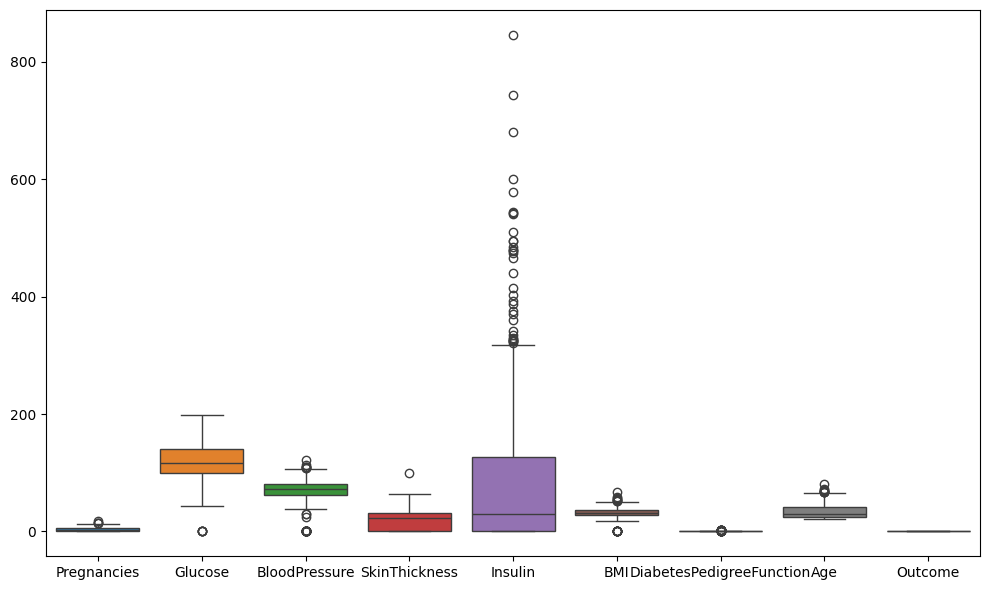

In [91]:
plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.tight_layout()

Outliers are there, and need the scaling, we can use  Robust Scaling.

C:\Users\user\AppData\Local\Temp\ipykernel_20340\2365973029.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Insulin'])
C:\Users\user\AppData\Local\Temp\ipykernel_20340\2365973029.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['BMI'])


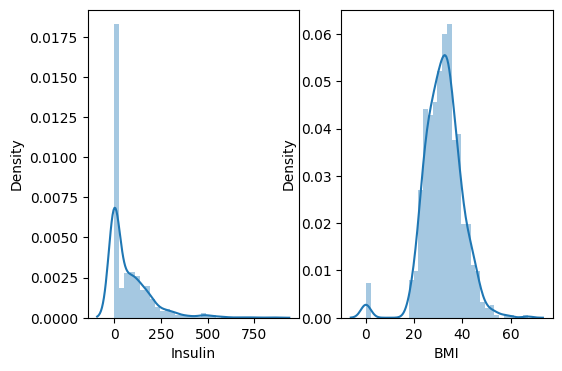

In [92]:
plt.figure(figsize=(6,4))

plt.subplot(1,2,1)
sns.distplot(df['Insulin'])

plt.subplot(1,2,2)
sns.distplot(df['BMI'])

plt.show()

In [93]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Dataset is imbalance as target column class label has a large difference

0    500
1    268

Need to Balance the dataset, we use Most popular SMOTE.

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline

We use imblearn.pipeline.Pipeline because it supports sampling techniques like SMOTE, ADASYN, and RandomUnderSampler. These samplers change both the feature matrix (X) and the target (y) using fit_resample(), whereas sklearn.pipeline.Pipeline only supports transformers that implement fit() and transform().

In [95]:
from sklearn.preprocessing import StandardScaler,RobustScaler
from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)

In [96]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [97]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [98]:
#("std",StandardScaler(),['Pregnancies',	'Glucose','BloodPressure','SkinThickness','BMI','DiabetesPedigreeFunction',	'Age']),

In [128]:
preprocess = ColumnTransformer(
    transformers=
    [
        ("std",StandardScaler(),['Pregnancies',	'Glucose','BloodPressure','SkinThickness','BMI','DiabetesPedigreeFunction',	'Age']),
        ("Robust",RobustScaler(),['Insulin'])
    ],
    remainder = 'passthrough'
)

In [122]:
from imblearn.over_sampling import SMOTE

# Preprocessing
X_train_scaled = preprocess.fit_transform(x_train)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

Outcome
0    401
1    213
Name: count, dtype: int64

Outcome
0    401
1    401
Name: count, dtype: int64


In [129]:
from sklearn.naive_bayes import GaussianNB

In [130]:
model = GaussianNB()

In [131]:
main_pipeline = Pipeline(
    steps=[
        ("pre",preprocess),
        ("smote",SMOTE(random_state =42)),
        ("model",GaussianNB())
    ]
)

In [132]:
main_pipeline.fit(x_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('Robust', RobustScaler(),
                                                  ['Insulin'])])),
                ('smote', SMOTE(random_state=42)), ('model', GaussianNB())])

In [133]:
y_pred_test = main_pipeline.predict(x_test)
y_pred_train = main_pipeline.predict(x_train)

In [134]:
from sklearn.metrics import accuracy_score

In [135]:
print(accuracy_score(y_test,y_pred_test))

0.7207792207792207


In [136]:
print(accuracy_score(y_train,y_pred_train))

0.744299674267101


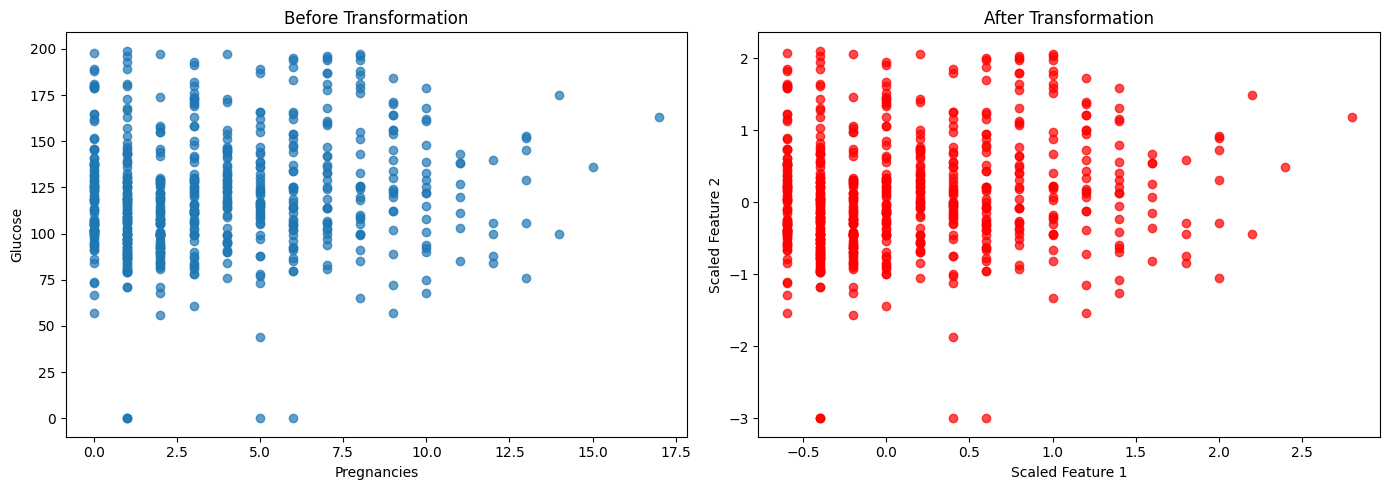

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Before Transformation
plt.subplot(1,2,1)
plt.scatter(
    x_train.iloc[:,0],
    x_train.iloc[:,1],
    alpha=0.7
)
plt.title("Before Transformation")
plt.xlabel(x_train.columns[0])
plt.ylabel(x_train.columns[1])

# After Transformation
plt.subplot(1,2,2)
plt.scatter(
    X_train_scaled[:,0],
    X_train_scaled[:,1],
    alpha=0.7,
    color="red"
)
plt.title("After Transformation")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")

plt.tight_layout()
plt.show()

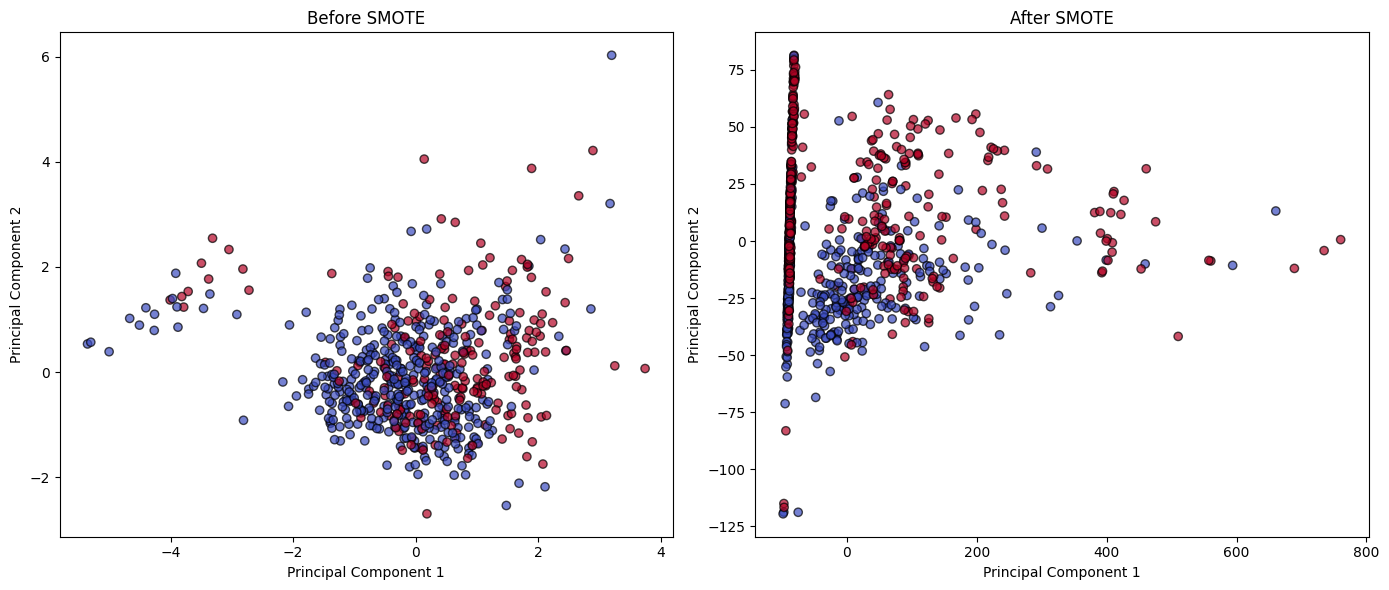

In [127]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce original data to 2D
pca = PCA(n_components=2)

X_before = pca.fit_transform(X_train_scaled)

# Reduce SMOTE data to 2D
X_after = pca.fit_transform(X_train_smote)

plt.figure(figsize=(14,6))

# Before SMOTE
plt.subplot(1,2,1)
plt.scatter(
    X_before[:,0],
    X_before[:,1],
    c=y_train,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.7
)
plt.title("Before SMOTE")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# After SMOTE
plt.subplot(1,2,2)
plt.scatter(
    X_after[:,0],
    X_after[:,1],
    c=y_train_smote,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.7
)
plt.title("After SMOTE")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()